## NOTEBOOK 1 - CHUNKING EXPERIMENT


In [6]:
# setup - import libraries

import sys
sys.path.insert(0, '..')

from langchain.text_splitter import RecursiveCharacterTextSplitter
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
# Sample document text (upload PDF Here)
sample_text = """
Artificial intelligence (AI) is intelligence demonstrated by machines.
Machine learning is a method of data analysis that automates analytical model building.
Deep learning is part of a broader family of machine learning methods.
Natural language processing (NLP) is a subfield of linguistics and computer science.
Computer vision is an interdisciplinary scientific field that deals with how computers gain understanding from digital images.
Retrieval Augmented Generation (RAG) is a technique that combines information retrieval with text generation.
Vector databases are specialized databases designed to store and query high-dimensional vectors.
Embeddings are numerical representations of text that capture semantic meaning.
Large language models (LLMs) are AI models trained on large amounts of text data.
Transformers are a type of neural network architecture that has revolutionized NLP tasks.
""" * 30  # repeat kar rahe hain taaki enough content ho

print(f'Total characters: {len(sample_text)}')
print(f'Total words: {len(sample_text.split())}')

Total characters: 27060
Total words: 3750


In [9]:
# Experiment 1 — Different chunk sizes compare karo
chunk_sizes = [100, 200, 300, 500, 800, 1000]
results = []

for size in chunk_sizes:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=size,
        chunk_overlap=50,
        separators=['\n\n', '\n', '.', ' ']
    )
    chunks = splitter.split_text(sample_text)
    avg_len = sum(len(c) for c in chunks) / len(chunks)
    results.append({
        'chunk_size': size,
        'num_chunks': len(chunks),
        'avg_chunk_len': round(avg_len, 1),
        'sample': chunks[0][:100] + '...'
    })
    print(f'Size {size:4d} | Chunks: {len(chunks):3d} | Avg len: {avg_len:.0f} chars')

df = pd.DataFrame(results)
print('\nSummary table:')
print(df[['chunk_size', 'num_chunks', 'avg_chunk_len']])

Size  100 | Chunks: 420 | Avg len: 70 chars
Size  200 | Chunks: 180 | Avg len: 149 chars
Size  300 | Chunks: 120 | Avg len: 224 chars
Size  500 | Chunks:  60 | Avg len: 450 chars
Size  800 | Chunks:  60 | Avg len: 450 chars
Size 1000 | Chunks:  30 | Avg len: 900 chars

Summary table:
   chunk_size  num_chunks  avg_chunk_len
0         100         420           69.7
1         200         180          149.2
2         300         120          224.2
3         500          60          449.5
4         800          60          449.5
5        1000          30          900.0


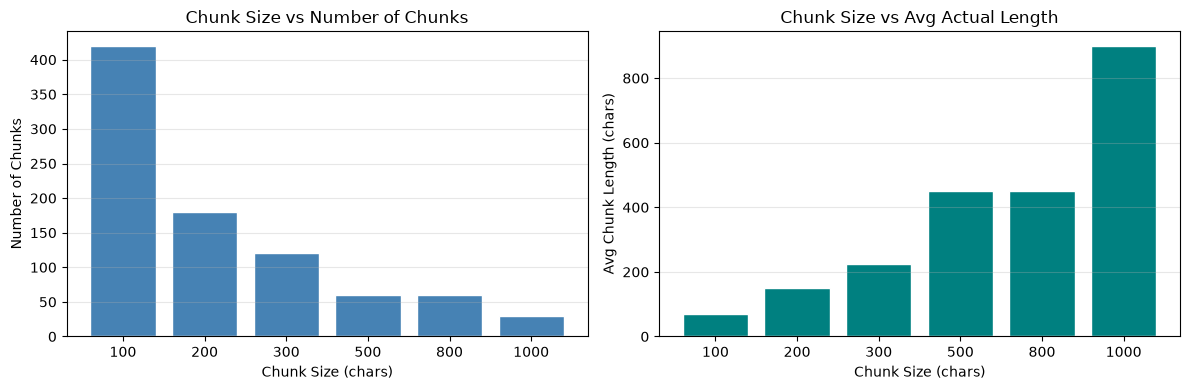

In [10]:
# Experiment 2 — Chunk size vs number of chunks graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(df['chunk_size'].astype(str), df['num_chunks'], color='steelblue', edgecolor='white')
ax1.set_title('Chunk Size vs Number of Chunks')
ax1.set_xlabel('Chunk Size (chars)')
ax1.set_ylabel('Number of Chunks')
ax1.grid(axis='y', alpha=0.3)

ax2.bar(df['chunk_size'].astype(str), df['avg_chunk_len'], color='teal', edgecolor='white')
ax2.set_title('Chunk Size vs Avg Actual Length')
ax2.set_xlabel('Chunk Size (chars)')
ax2.set_ylabel('Avg Chunk Length (chars)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chunk_size_analysis.png', dpi=100, bbox_inches='tight')
plt.show()


In [11]:
# Experiment 3 — Effect of overlap
overlaps = [0, 20, 50, 80, 100, 150]
overlap_results = []

for overlap in overlaps:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=300,  # fixed size
        chunk_overlap=overlap
    )
    chunks = splitter.split_text(sample_text)
    overlap_results.append({
        'overlap': overlap,
        'num_chunks': len(chunks)
    })
    print(f'Overlap {overlap:3d} | Chunks: {len(chunks)}')

print('\nConclusion: more overlap = more chunks = more storage')
print('Recommended: overlap = chunk_size * 0.15 to 0.20')

Overlap   0 | Chunks: 120
Overlap  20 | Chunks: 120
Overlap  50 | Chunks: 120
Overlap  80 | Chunks: 120
Overlap 100 | Chunks: 120
Overlap 150 | Chunks: 150

Conclusion: more overlap = more chunks = more storage
Recommended: overlap = chunk_size * 0.15 to 0.20


In [12]:
# Experiment 4 — Context boundary test
# Check if important sentences are getting split between chunks

test_text = """Section 1: Introduction.
This is the first paragraph with important information about AI.
The key finding is that neural networks outperform traditional methods.

Section 2: Methodology.
We used a dataset of 10,000 samples for training.
The model was trained for 100 epochs with a learning rate of 0.001.

Section 3: Results.
Our model achieved 94.5% accuracy on the test set.
This represents a 12% improvement over the baseline."""

splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=40
)
chunks = splitter.split_text(test_text)

print(f'Total chunks: {len(chunks)}')
print('=' * 50)
for i, chunk in enumerate(chunks):
    print(f'\nChunk {i+1}:')
    print(chunk)
    print('-' * 30)

Total chunks: 3

Chunk 1:
Section 1: Introduction.
This is the first paragraph with important information about AI.
The key finding is that neural networks outperform traditional methods.
------------------------------

Chunk 2:
Section 2: Methodology.
We used a dataset of 10,000 samples for training.
The model was trained for 100 epochs with a learning rate of 0.001.
------------------------------

Chunk 3:
Section 3: Results.
Our model achieved 94.5% accuracy on the test set.
This represents a 12% improvement over the baseline.
------------------------------


In [14]:
# FINAL RECOMMENDATION
print('=' * 50)
print('RECOMMENDED SETTINGS FOR THIS PROJECT')
print('=' * 50)
print()
print('CHUNK_SIZE   = 300  (good balance: specific enough for retrieval)')
print('CHUNK_OVERLAP = 60  (20% of chunk_size: prevents context loss)')
print()
print('Update in .env file :')
print('CHUNK_SIZE=300')
print('CHUNK_OVERLAP=60')

RECOMMENDED SETTINGS FOR THIS PROJECT

CHUNK_SIZE   = 300  (good balance: specific enough for retrieval)
CHUNK_OVERLAP = 60  (20% of chunk_size: prevents context loss)

Update in .env file :
CHUNK_SIZE=300
CHUNK_OVERLAP=60
